# Titanic (Kaggle)
## 1. imports

In [233]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

## 2. Load Data

In [234]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Quick checks

In [235]:
print(train.isna().sum().sort_values(ascending=False).head(5))
print("-" * 30)
print(test.isna().sum().sort_values(ascending=False).head(5))

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
dtype: int64
------------------------------
Cabin     327
Age        86
Fare        1
Name        0
Pclass      0
dtype: int64


## 4. Cleaning + encoding

In [236]:
def preprocess_data(train, test):
    train = train.copy()
    test = test.copy()

    # Save PassengerId for submission
    test_ids = test["PassengerId"].copy()

    # Fill missing values
    median_age = train["Age"].median()
    train["Age"] = train["Age"].fillna(median_age)
    test["Age"] = test["Age"].fillna(median_age)

    test["Fare"] = test["Fare"].fillna(train["Fare"].median())

    mode_emb = train["Embarked"].mode()[0]
    train["Embarked"] = train["Embarked"].fillna(mode_emb)
    test["Embarked"] = test["Embarked"].fillna(mode_emb)

    # Drop Cabin
    train.drop("Cabin", axis=1, inplace=True, errors="ignore")
    test.drop("Cabin", axis=1, inplace=True, errors="ignore")

    # Drop unused columns
    train.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
    test.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

    # Encode Sex
    train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
    test["Sex"] = test["Sex"].map({"male": 0, "female": 1})

    # Encode Embarked
    emb_map = {"S": 0, "C": 1, "Q": 2}
    train["Embarked"] = train["Embarked"].map(emb_map)
    test["Embarked"] = test["Embarked"].map(emb_map)

    y = train["Survived"]
    X = train.drop("Survived", axis=1)

    return X, y, test, test_ids

In [237]:
X, y, X_test, test_ids = preprocess_data(train, test)


print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (891, 7)
Test shape: (418, 7)


## 5. Train

In [238]:
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
model.fit(X, y)

print("CV accuracy:", scores.mean())

CV accuracy: 0.7934906785512524


## 6. create submission

In [239]:
preds = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": preds
})

submission_path = Path("../output/submissions/submission.csv")
submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
submission.head()

Submission saved to: ../output/submissions/submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## 7. simple diagram

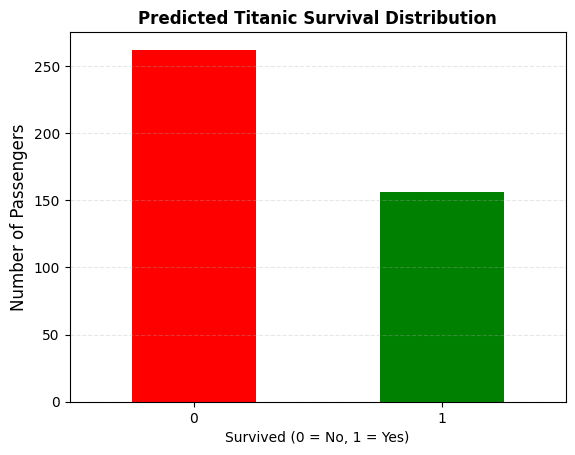

In [240]:
survival_counts = submission["Survived"].value_counts()

survival_counts.plot(kind="bar", color=["red", "green"])
plt.title("Predicted Titanic Survival Distribution", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks(rotation=0)
plt.show()